 # **Tarea #3 - Ciencia de Redes (MII 2025-2)**

    Autor: David Cáceres Ovalle
    Profesor: Wenceslao Palma
    Fecha: 06 de Diciembre de 2025


# (a) Redacte un resumen de los principales puntos del paper (con extensión máxima de 1 página), deberá resumir los principales resultados (las secciones pueden variar, esto es solo una guía):

## Introducción
Los sistemas de metro son componentes integrales del transporte urbano y sus fallas pueden tener impactos graves en la movilidad. Este paper aborda la necesidad crítica de medir la robustez de estas infraestructuras físicas considerándolas como entidades topológicas mediante la ciencia de redes. El estudio investiga el rendimiento de diversas métricas de robustez (teóricas y numéricas) frente a fallas aleatorias y ataques dirigidos, con el objetivo de cuantificar la capacidad de estos sistemas para soportar estrés antes de colapsar.

## Metodología
El estudio analiza 33 redes de metro a nivel mundial utilizando el siguiente enfoque:

* **Construcción de la Red:** Se modelan como grafos no dirigidos $G(N,L)$, donde los nodos ($N$) representan estaciones de transferencia y terminales, y los enlaces ($L$) son las vías. Las estaciones que no permiten transferencias se excluyen para evitar sesgos en la topología.
* **Métricas Teóricas:** Se calculan diez métricas para anticipar la influencia de fallas, incluyendo el indicador de robustez ($r^T$), la conductancia efectiva del grafo ($C_G$), la eficiencia global ($E[1/H]$) y la conectividad algebraica, entre otros.
* **Métricas Numéricas (Simulación):** Se obtienen umbrales críticos mediante simulaciones de eliminación progresiva de nodos (tanto aleatoria como basada en el grado). Se definen dos umbrales principales: $f_{90\%}$ (fracción de nodos removidos para que el componente gigante se reduzca al 90%) y $f_c$ (colapso total o desintegración de la red).
* **Análisis:** Se utiliza la correlación de Pearson para comparar las métricas teóricas con los umbrales experimentales y se generan diagramas de radar para una evaluación visual multicriterio.

## Resultados
El análisis revela que la robustez no es un concepto unidimensional, sino que las métricas teóricas capturan dos aspectos distintos y a menudo contradictorios:

1.  **Caminos Alternativos (Redundancia):** Métricas como el indicador de robustez ($r^T$) enfatizan la existencia de múltiples rutas. Tokio destaca bajo este criterio ($\overline{r^T}=0.512$), siendo la red más robusta en este aspecto gracias a sus múltiples ciclos y opciones de transferencia.
2.  **Longitud del Camino (Resistencia/Eficiencia):** Métricas como la conductancia efectiva ($C_G$) enfatizan la eficiencia y las distancias cortas. Roma destaca bajo este criterio ($C_G=0.25$) debido a distancias de transferencia cortas y una topología tipo estrella eficiente.

Se encontró una fuerte correlación positiva entre $C_G$ y el umbral de falla inicial ($f_{90\%}$), mientras que $r^T$ correlaciona mejor con el punto de colapso total ($f_c$). Existe una contradicción inherente de diseño: optimizar la redundancia (aumentar $r^T$) tiende a disminuir la conductancia ($C_G$). Al combinar todas las métricas en diagramas de radar para una visión holística, Tokio y Roma emergen como las redes más robustas globalmente.

## Conclusiones
La robustez de las redes de metro es una propiedad multifacética que no puede ser capturada por una sola medida aislada. Las redes más exitosas equilibran dos estrategias: ofrecer múltiples caminos alternativos (como Tokio) y mantener distancias cortas entre transferencias (como Roma).

Para la planificación futura de redes de transporte, el estudio recomienda:
* Crear estaciones de transferencia tanto en el centro como en la periferia para aumentar las rutas alternativas.
* Mantener los segmentos de línea sin transferencias lo más cortos posible para minimizar el impacto de fallas individuales y mejorar la "resistencia" general del sistema.

# (b) Replique los experimentos y concluya. En caso que las redes del paper no se encuentren disponibles utilice
Segun el encabezado de la tarea, se sugiere utilizar el dataset "A collection of public transport network data sets for 25 cities"

Este dataset proporciona datos detallados sobre las redes de transporte público de 25 ciudades de todo el mundo. Su objetivo es facilitar el acceso a esta información en formatos fáciles de usar para la investigación y el análisis, este dataset contiene informacion obtenida en su ultima versión(1.2) de Feb 28, 2018.

> Al ser un data set del 2018, se decidio buscar si existia otro que fuera mas reciente y enfocado en el analisis que se solicita. En esta busqueda se encontro "A curated data set of L-space representations for 51 metro networks worldwide"

#1.- Dataset a utilizar para realizar la replicación de los experimentos

##**51 Redes de Metro**
**Título:** *A curated data set of L-space representations for 51 metro networks worldwide*
**Fuente:** [4TU.ResearchData](https://data.4tu.nl/articles/dataset/A_curated_data_set_of_L-space_representations_for_51_metro_networks_worldwide/21316824/1) publicada el 19 de octubre del 2022

###Descripción General
Este dataset contiene la representación topológica de sistemas de metro de **51 ciudades**. A diferencia de los datos brutos de transporte, este conjunto ha sido curado manualmente para asegurar la calidad de la estructura de la red, eliminando errores comunes en los feeds públicos.

El data set es un conjunto de datos seleccionados de representaciones en espacio L en formato .json. La creación de este conjunto de datos formó parte de la tesis de maestría que se menciona a continuación. El objetivo era crear un conjunto de representaciones topológicas basadas en datos GTFS (General Transit Feed Specification) seleccionados y verificados. Cada archivo es un grafo que contiene un conjunto de nodos y aristas para cada red, junto con información adicional.

> Vijlbrief, S. (2022). Including service information in a topological comparison of metro networks worldwide: A comparison of 51 metro networks worldwide using GTFS static data [Master’s thesis, Delft University of Technology].
[Repositorio](https://resolver.tudelft.nl/uuid:5197db6d-1b39-413d-bf24-2ee13639e590)


###Características Técnicas

* **Modelo de Red (L-space):**
    * **Nodos:** Representan las estaciones.
    * **Aristas:** Representan las conexiones físicas directas (vías/túneles) entre estaciones consecutivas.
* **Formato:**
    * Archivos `.json` individuales por ciudad (contienen la estructura de grafo).
    * Metadatos en `.xlsx` con detalles del procesamiento temporal.
* **Origen:** Derivado de datos GTFS (General Transit Feed Specification) y verificado para consistencia topológica.

##2.- Pre-procesamiento de Datos: Simplificación Topológica

###Contexto del Problema
Al intentar replicar los experimentos del paper, se detectó una discrepancia significativa entre las métricas obtenidas con los datos brutos (archivos `.json` originales) y los valores reportados en la **Tabla 1** del paper.

Los archivos originales contienen la **topología física completa** de la red, incluyendo todas las estaciones de paso. Sin embargo, el análisis de robustez estructural requiere una abstracción de la red para evitar sesgos estadísticos.

###Metodología de Construcción de la Red
Según la metodología descrita en la Sección 3.1 del paper, la construcción del grafo $G(N, L)$ sigue una regla estricta:

> "Solo se tienen en cuenta las **terminales** y las **estaciones de transferencia**; no se consideran otras estaciones intermedias que no ofrecen transferencias o no finalizan líneas."

> En el paper justifican esta decisión indicando que las estaciones de paso (grado $k=2$) tienden a sesgar los resultados de métricas topológicas, ya que simplemente conectan dos estaciones adyacentes sin añadir complejidad estructural.

###Algoritmo de Simplificación Implementado
Para alinear los datos con la forma utilizada en el paper, se implementó un script de **reducción topológica** que transforma la red física en una red lógica de transferencias. El proceso realizado automáticamente por el script es el siguiente:

1.  **Identificación:** Se identifican todos los nodos con grado $k=2$ (estaciones que solo tienen una entrada y una salida).
2.  **Contracción (Bypass):** Para cada nodo de grado 2 identificado, se crea un enlace directo entre sus dos vecinos (preservando la conectividad de la línea).
3.  **Eliminación:** Se elimina el nodo de grado 2 de la red.
4.  **Iteración:** Este proceso se repite iterativamente hasta que la red solo contiene nodos con $k=1$ (terminales) o $k \geq 3$ (hubs/transferencias), cumpliendo con la definición de $N$ del paper.

### Resultado
Este pre-procesamiento reduce drásticamente el número de nodos ($N$) y enlaces ($L$), permitiendo calcular las métricas teóricas ($r^T$, $C_G$, Eficiencia) y los umbrales de robustez ($f_{90\%}$, $f_c$) bajo las mismas condiciones que lo realizado en el paper.

* **Red Original:** Representación geográfica detallada (útil para mapas).
* **Red Procesada:** Representación topológica abstracta (necesaria para el análisis de robustez).

In [ ]:
# @title Imports y dict con definiciones en latex
import os
import glob
import json
import networkx as nx
import numpy as np
import pandas as pd
from scipy import linalg
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from networkx.readwrite import json_graph

latex_cols = {

    'r_T_med': r'$\overline{r^T}$',
    'r_T': r'${r^T}$',
    'C_G': r'$C_G$',
    'Rel_G': r'$Rel_G$',
    'Efficiency': r'$E[\frac{1}{H}]$',
    'Clustering': r'$CC_G$',
    'Alg_Conn': r'$\overline{\mu_{N-1}}$',
    'Avg_Deg': r'$\overline{E[D]}$',
    'Nat_Conn': r'$\overline{\lambda}^*$',
    'Inv_Kappa': r'$1/\kappa$',
    'Meshedness': r'$M_G$',
    'f90_Targeted': r'$f_{90\%}{-degree}$',
    'f90_Random': r'$f_{90\%}{-random}$',
    'fc_Targeted': r'$f_{c}{-degree}$',
    'fc_Random': r'$f_{c}{-random}$',
    'Kappa':r'$\kappa$',
    'Area': 'Area'
}


In [ ]:
# @title Funciones que procesan los archivos originales y reducen la topologia de la red (k != 2)


def simplify_to_paper_topology(G_original):
    """
    Reduce la red conservando solo terminales y estaciones de transferencia (k != 2).
    """
    G = G_original.copy()
    changed = True
    while changed:
        changed = False
        nodes = list(G.nodes())
        for node in nodes:
            if G.has_node(node) and G.degree(node) == 2:
                neighbors = list(G.neighbors(node))
                u, v = neighbors[0], neighbors[1]
                if u == v: continue

                # Bypass: conectar vecinos entre sí
                if not G.has_edge(u, v):
                    G.add_edge(u, v)

                G.remove_node(node)
                changed = True
                break

    # Vuelve a enumerar los nodos para que los IDs sean consecutivos (0, 1, 2...)
    G = nx.convert_node_labels_to_integers(G, first_label=0)
    return G


In [ ]:
# @title Generacion de red desde archivos
def load_metro_json(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)

    G = nx.Graph()

    for node in data['nodes']:
        G.add_node(
            node['id'],
            pos=(node['lon'], node['lat']),
            name=node['name'],
            original_ids=node.get('original_ids', [])
        )

    def first_key(d, default=None):
        if isinstance(d, dict) and len(d) > 0:
            return next(iter(d.keys()))
        return default

    for link in data['links']:
        u = link['source']
        v = link['target']
        if u == v:
            continue

        route_id    = first_key(link.get('route_I_counts', {}))
        shape_id    = first_key(link.get('shape_id', {}))
        direction_k = first_key(link.get('direction_id', {}))
        headsign    = first_key(link.get('headsign', {}))

        try:
            direction_id = int(direction_k) if direction_k is not None else None
        except ValueError:
            direction_id = None

        G.add_edge(
            u, v,
            duration_seg_avg = link.get('duration_avg'),
            n_vehicles   = link.get('n_vehicles'),
            distance_mts     = link.get('d'),
            route_id     = route_id,
            shape_id     = shape_id,
            direction_id = direction_id,
            headsign     = headsign,
            route_I_counts = link.get('route_I_counts'),
            shape_id_raw   = link.get('shape_id'),
            direction_raw  = link.get('direction_id'),
            headsign_raw   = link.get('headsign')
        )
 # Analizar componentes y avisar si hay más de una
    if len(G) > 0:
        components = list(nx.connected_components(G))
        n_comp = len(components)

        if n_comp > 1:
            sizes = sorted((len(c) for c in components), reverse=True)
            print(
                f"[AVISO] {os.path.basename(filepath)} tiene {n_comp} componentes "
                f"conexas. Tamaños (descendentes): {sizes}"
            )
    # Mantener solo la componente gigante
    if len(G) > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    return G

def get_location_info(filename):
    base = os.path.splitext(filename)[0]
    parts = base.split('-')
    if len(parts) >= 2:
        return parts[0].title(), "-".join(parts[1:]).title()
    return "Unknown", base.title()

In [ ]:
# @title Funciones para calculo de metricas teoricas y ataque


def calculate_theoretical_metrics(G):
    N = G.number_of_nodes()
    L = G.number_of_edges()
    if N < 2: return {}

    # Matrices y Espectros
    adj_mat = nx.adjacency_matrix(G).todense()
    lap_mat = nx.laplacian_matrix(G).todense()

    # Eigenvalues
    mu = np.real(linalg.eigvals(lap_mat)) # Laplaciano
    mu = np.sort(mu)
    lam = np.real(linalg.eigvals(adj_mat)) # Adyacencia (para Natural Conn)

    # --- 1. r^T (Robustness Indicator) ---
    arg = L - N + 2
    r_T = np.log(arg) / N if arg > 0 else 0

    # --- 2. C_G (Effective Graph Conductance) ---
    valid_mu = mu[1:][mu[1:] > 1e-9]
    if len(valid_mu) > 0:
        R_G = N * np.sum(1 / valid_mu)
        C_G = (N - 1) / R_G
    else:
        C_G = 0

    # --- 3. Reliability (Rel_G) ---
    # Aproximación por Monte Carlo (p=0.999 link reliability)
    # El paper usa 0.999. Si hay puentes (bridges), Rel baja drásticamente.
    num_bridges = len(list(nx.bridges(G)))
    # Aproximación rápida para redes conectadas con alta fiabilidad:
    # Rel ~ p^(num_bridges). Si p=0.999, Rel ~ 0.999^puentes.
    # Para ser más exactos usamos simulación simple:
    p_link = 0.999
    num_sims = 100 # Simulación rápida
    connected_count = 0
    for _ in range(num_sims):
        G_sim = G.copy()
        # Eliminar enlaces con prob (1-p)
        edges = list(G_sim.edges())
        remove_mask = np.random.random(len(edges)) > p_link
        edges_to_remove = [e for i, e in enumerate(edges) if remove_mask[i]]
        G_sim.remove_edges_from(edges_to_remove)
        if nx.is_connected(G_sim):
            connected_count += 1
    Rel_G = connected_count / num_sims

    # --- 4. Efficiency E[1/H] ---
    E_inv_H = nx.global_efficiency(G)

    # --- 5. Clustering CC_G ---
    CC_G = nx.average_clustering(G)

    # --- 6. Algebraic Connectivity mu_N-1 ---
    alg_conn = mu[1] / N if len(mu) > 1 else 0

    # --- 7. Average Degree E[D] ---
    degrees = np.array([d for n, d in G.degree()])
    E_D = np.mean(degrees)
    E_D_norm = E_D / (N - 1)

    # --- 8. Natural Connectivity (lambda_bar) ---
    # ln( (1/N) * sum(e^lambda_i) )
    avg_exp_lambda = np.mean(np.exp(lam))
    nat_conn = np.log(avg_exp_lambda) if avg_exp_lambda > 0 else 0
    # Normalizamos dividiendo por N - ln(N) (valor aprox grafo completo)
    nat_conn_norm = nat_conn / (N - np.log(N)) if N > 1 else 0

    # --- 9. Degree Diversity (1/kappa) ---
    # kappa = <k^2> / <k>. Paper usa inversa: 1/kappa = <k> / <k^2>
    moment_1 = np.mean(degrees)
    moment_2 = np.mean(degrees**2)
    inv_kappa = moment_1 / moment_2 if moment_2 > 0 else 0
    kappa = moment_2 / moment_1 if moment_1 > 0 else 0


    # --- 10. Meshedness M_G ---
    denom = 2 * N - 5
    M_G = (L - N + 1) / denom if denom > 0 else 0

    return {
        "N": N, "L": L,
        "r_T": r_T,
        "C_G": C_G,
        "Rel_G": Rel_G,
        "Efficiency": E_inv_H,
        "Clustering": CC_G,
        "Alg_Conn": alg_conn,
        "Avg_Deg": E_D_norm,
        "Nat_Conn": nat_conn_norm,
        "Inv_Kappa": inv_kappa,
        "Meshedness": M_G,
        "Kappa": kappa,
    }

def run_attack_simulation(G, attack_type='random'):
    G_temp = G.copy()
    initial_size = G.number_of_nodes()
    lcc_history = [initial_size]

    nodes_to_remove = list(G.nodes())

    if attack_type == 'random':
        np.random.shuffle(nodes_to_remove)
    elif attack_type == 'targeted':
        nodes_degree = sorted(G.degree, key=lambda x: x[1], reverse=True)
        nodes_to_remove = [n for n, d in nodes_degree]

    for node in nodes_to_remove:
        if node in G_temp:
            G_temp.remove_node(node)

        if len(G_temp) > 0:
            lcc = len(max(nx.connected_components(G_temp), key=len))
        else:
            lcc = 0
        lcc_history.append(lcc)

    return lcc_history

def calculate_thresholds(lcc_curve, N):
    f_90, f_c = None, None
    limit_90 = 0.90 * N

    for i, size in enumerate(lcc_curve):
        frac = i / N
        if f_90 is None and size < limit_90: f_90 = frac
        if f_c is None and size <= 1:
            f_c = frac
            break

    return (f_90 if f_90 else 1.0), (f_c if f_c else 1.0)



In [ ]:
# @title Procesamiento de archivos y csv con analisis de las redes

folder_path = "data"
output_folder = "topologia"
json_files = glob.glob(os.path.join(folder_path, "*.json"))
results_list = []

os.makedirs(output_folder, exist_ok=True)

for filepath in json_files:
    filename = os.path.basename(filepath)
    country, city = get_location_info(filename)

    print(f"Procesando {city} ({country})...", end=" \n")

    try:
        # Cargar Original
        G_full = load_metro_json(filepath)
        G = simplify_to_paper_topology(G_full)

        base_name = os.path.splitext(filename)[0]
        output_path = os.path.join(output_folder, f"{city}-{country}_topologia.json")
        G_data = json_graph.node_link_data(G)
        with open(output_path, "w", encoding="utf-8") as f_out:
            json.dump(G_data, f_out, ensure_ascii=False, indent=2)

        N_total = G.number_of_nodes()

        N_orig = G_full.number_of_nodes()

        # Métricas sobre la red simplificada
        metrics = calculate_theoretical_metrics(G)
        metrics['Country'] = country
        metrics['City'] = city

        # Simulaciones sobre la red simplificada
        # Random (x10)
        f90_rnd, fc_rnd = [], []
        for _ in range(10):
            curve = run_attack_simulation(G, 'random')
            f90, fc = calculate_thresholds(curve, N_total)
            f90_rnd.append(f90); fc_rnd.append(fc)

        metrics['f90_Random'] = round(np.mean(f90_rnd), 3)
        metrics['fc_Random'] = round(np.mean(fc_rnd), 3)

        # Targeted (x1)
        curve_tgt = run_attack_simulation(G, 'targeted')
        f90_tgt, fc_tgt = calculate_thresholds(curve_tgt, N_total)
        metrics['f90_Targeted'] = round(f90_tgt, 3)
        metrics['fc_Targeted'] = round(fc_tgt, 3)
        results_list.append(metrics)

    except Exception as e:
        print(f"Error: {e}")

# --- Guardar CSV ---
if results_list:
    df = pd.DataFrame(results_list)

    # Orden de columnas actualizado
    cols = ['Country', 'City', 'N', 'L', 'r_T', 'C_G', 'Efficiency',
            'Clustering', 'Alg_Conn', 'Avg_Deg', 'Meshedness','Rel_G', 'Nat_Conn','Kappa', 'Inv_Kappa',
            'f90_Targeted', 'f90_Random', 'fc_Targeted', 'fc_Random']

    final_cols = [c for c in cols if c in df.columns]
    df_final = df[final_cols].sort_values(by=['City', 'Country'])

    df_final.to_csv("resultados_metro_robustez_completo.csv", index=False)
    print("\nGuardado como: 'resultados_metro_robustez_completo.csv'")


Procesando Copenhagen (Denmark)... 
Procesando Republic-Prague (Czech)... 
Procesando Kochi (India)... 
Procesando Bilbao (Spain)... 
Procesando Turin (Italy)... 
Procesando Baltimore (Usa)... 
Procesando Berlin (Germany)... 
Procesando Brussels (Belgium)... 
Procesando Toulouse (France)... 
Procesando Rennes (France)... 
Procesando Malaga (Spain)... 
Procesando Madrid (Spain)... 
Procesando Toronto (Canada)... 
Procesando Lille (France)... 
Procesando Nuremberg (Germany)... 
Procesando Valencia (Spain)... 
Procesando Stockholm (Sweden)... 
Procesando Santiago (Chile)... 
Procesando Montreal (Canada)... 
Procesando Cairo (Egypt)... 
Procesando Vancouver (Canada)... 
Procesando Vienna (Austria)... 
Procesando Philadelphia (Usa)... 
Procesando Amsterdam (Netherlands)... 
Procesando Rome (Italy)... 
Procesando Newyork (Usa)... 
Procesando Oslo (Norway)... 
Procesando Milan (Italy)... 
Procesando Losangeles (Usa)... 
Procesando Budapest (Hungary)... 
Procesando Washington (Usa)... 
Procesa

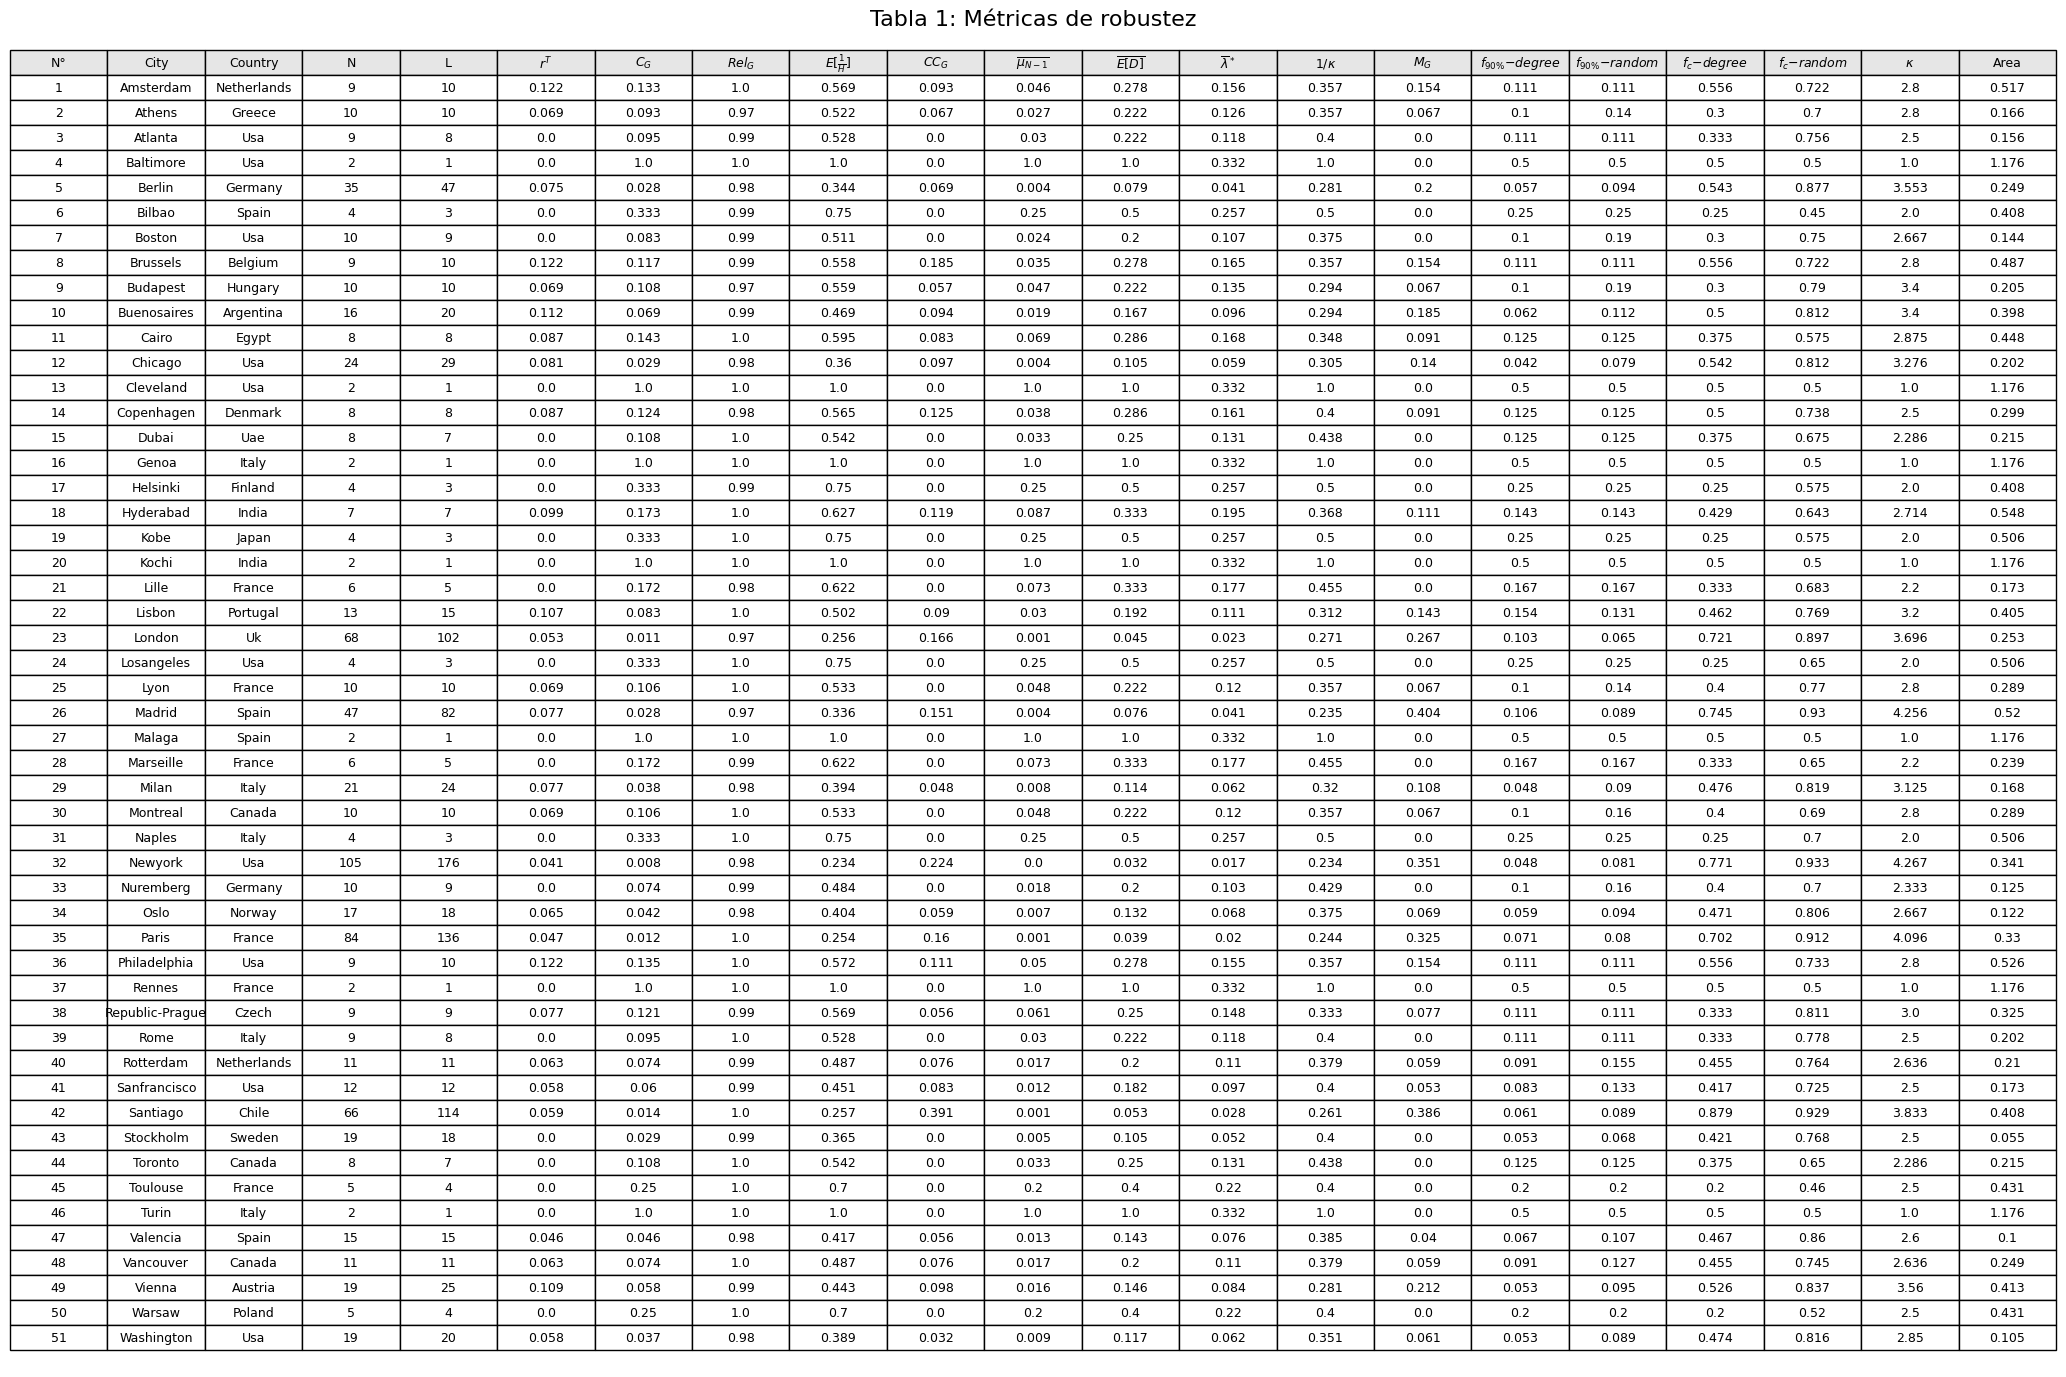

In [ ]:
# @title Tabla 1: Métricas de robustez
if results_list:
    df = pd.DataFrame(results_list)

    metrics_radar = [
        'r_T', 'C_G', 'Rel_G', 'Efficiency', 'Clustering',
        'Alg_Conn', 'Avg_Deg', 'Nat_Conn', 'Kappa', 'Meshedness'
    ]

    # Normalizar [0, 1]
    df_norm = df[metrics_radar].copy()
    for col in metrics_radar:
        mn, mx = df_norm[col].min(), df_norm[col].max()
        if mx - mn > 0:
            df_norm[col] = (df_norm[col] - mn) / (mx - mn)
        else:
            df_norm[col] = 0.5 # Default si no hay variación

    #Calcular Área del Polígono (Fórmula de Shoelace para radar regular)
    angles_diff = 2 * pi / len(metrics_radar) # 36 grados entre ejes

    areas = []
    for idx, row in df_norm.iterrows():
        vals = row.values.tolist()
        vals.append(vals[0]) # Cerrar el loop
        area_sum = sum(vals[i] * vals[i+1] for i in range(len(vals)-1))
        # Area = 0.5 * sin(angle) * sum(R_i * R_{i+1})
        polygon_area = 0.5 * np.sin(angles_diff) * area_sum
        areas.append(polygon_area)

    df['Area'] = areas
    df_final['Area']=areas


    cols_order = ['City','Country', 'N', 'L'] + list(latex_cols.keys())

    # Filtrar y ordenar
    final_cols = [c for c in cols_order if c in df.columns]
    df_viz = df[final_cols].copy()

    df_viz.sort_values(by='City', ascending=True, inplace=True)
    df_viz.insert(0, 'N°', range(1, len(df_viz) + 1))
    # Renombrar titulos apra utilizar latex y que se vean bien
    df_viz = df_viz.rename(columns=latex_cols)


    fig, ax = plt.subplots(figsize=(22, len(df_viz) * 0.32 + 1))
    ax.axis('tight')
    ax.axis('off')

    tabla = ax.table(
        cellText=df_viz.round(3).values,
        colLabels=df_viz.columns,
        loc='center',
        cellLoc='center'
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9)
    tabla.scale(1.2, 1.5)

    # Estilo encabezado
    for (row, col), cell in tabla.get_celld().items():
        if row == 0:
            cell.set_facecolor('#e6e6e6')

    plt.title("Tabla 1: Métricas de robustez", fontsize=16, y=1.0)
    fig.savefig("tabla1_metricas_robustes.png", dpi=300, bbox_inches='tight')

    plt.show()
    df.to_csv("tabla1_metricas_robustes.csv", index=False)



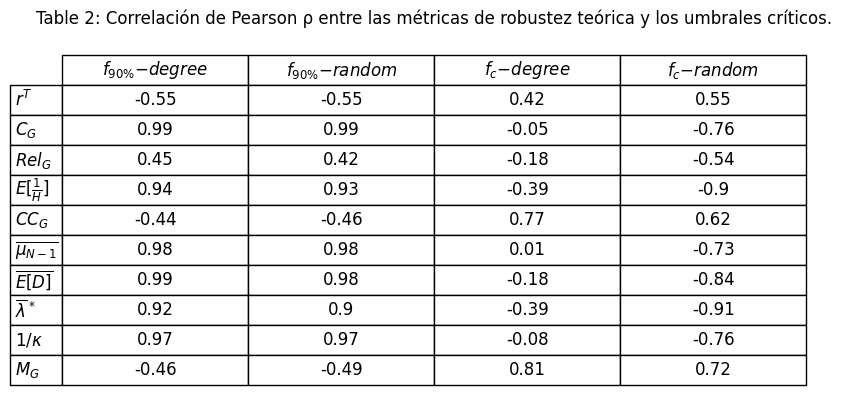

In [ ]:
# @title Tabla 2: Correlación de Pearson ρ entre las métricas de robustez teórica y los umbrales críticos.

filas = ['r_T', 'C_G','Rel_G', 'Efficiency', 'Clustering', 'Alg_Conn', 'Avg_Deg','Nat_Conn','Inv_Kappa', 'Meshedness']
columnas = ['f90_Targeted', 'f90_Random', 'fc_Targeted', 'fc_Random']

f_exist = [c for c in filas if c in df_final.columns]
c_exist = [c for c in columnas if c in df_final.columns]

corr_data = df_final[f_exist + c_exist].corr(method='pearson').loc[f_exist, c_exist]

tabla_paper = corr_data.rename(index=latex_cols, columns=latex_cols)


fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('tight')
ax.axis('off')

# Crear la tabla gráfica
tabla_plot = ax.table(
    cellText=tabla_paper.round(2).values,
    rowLabels=tabla_paper.index,
    colLabels=tabla_paper.columns,
    cellLoc='center',
    loc='center'
)

tabla_plot.auto_set_font_size(False)
tabla_plot.set_fontsize(12)
tabla_plot.scale(1.2, 1.8)
plt.title("Table 2: Correlación de Pearson ρ entre las métricas de robustez teórica y los umbrales críticos.", fontsize=12, pad=30)
fig.savefig("tabla2_correlacion_pearson_teorica_umbrales_Criticos.png", dpi=300, bbox_inches='tight')
tabla_paper.to_csv("tabla2_correlacion_pearson_teorica_umbrales_Criticos.csv", index=False)

plt.show()

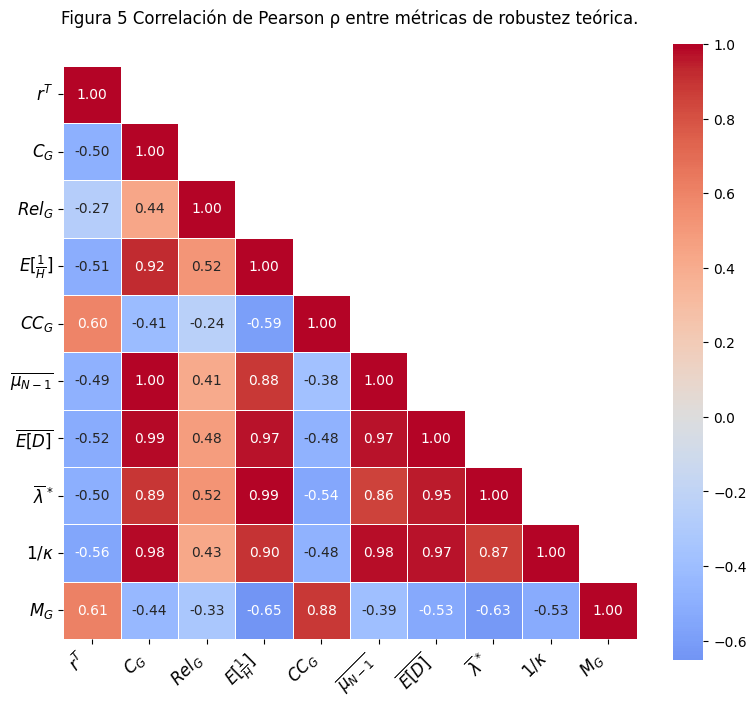

In [ ]:
# @title Figura 5 Correlación de Pearson ρ entre métricas de robustez teórica.

metricas_cols = [
    'r_T', 'C_G','Rel_G', 'Efficiency', 'Clustering',
    'Alg_Conn', 'Avg_Deg','Nat_Conn','Inv_Kappa', 'Meshedness'
]

cols_existentes = [c for c in metricas_cols if c in df_final.columns]
df_analysis = df_final[cols_existentes]



etiquetas_ejes = [latex_cols.get(col, col) for col in cols_existentes]

correlation_matrix = df_analysis.corr(method='pearson')

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1) # k=1, para ocultar triangulo superior

fig=plt.figure(figsize=(8, 8))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    xticklabels=etiquetas_ejes,
    yticklabels=etiquetas_ejes
)

plt.title("Figura 5 Correlación de Pearson ρ entre métricas de robustez teórica.", fontsize=12, pad=30)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
fig.savefig("fig5_correlacion_pearson.png", dpi=300, bbox_inches='tight')

plt.show()

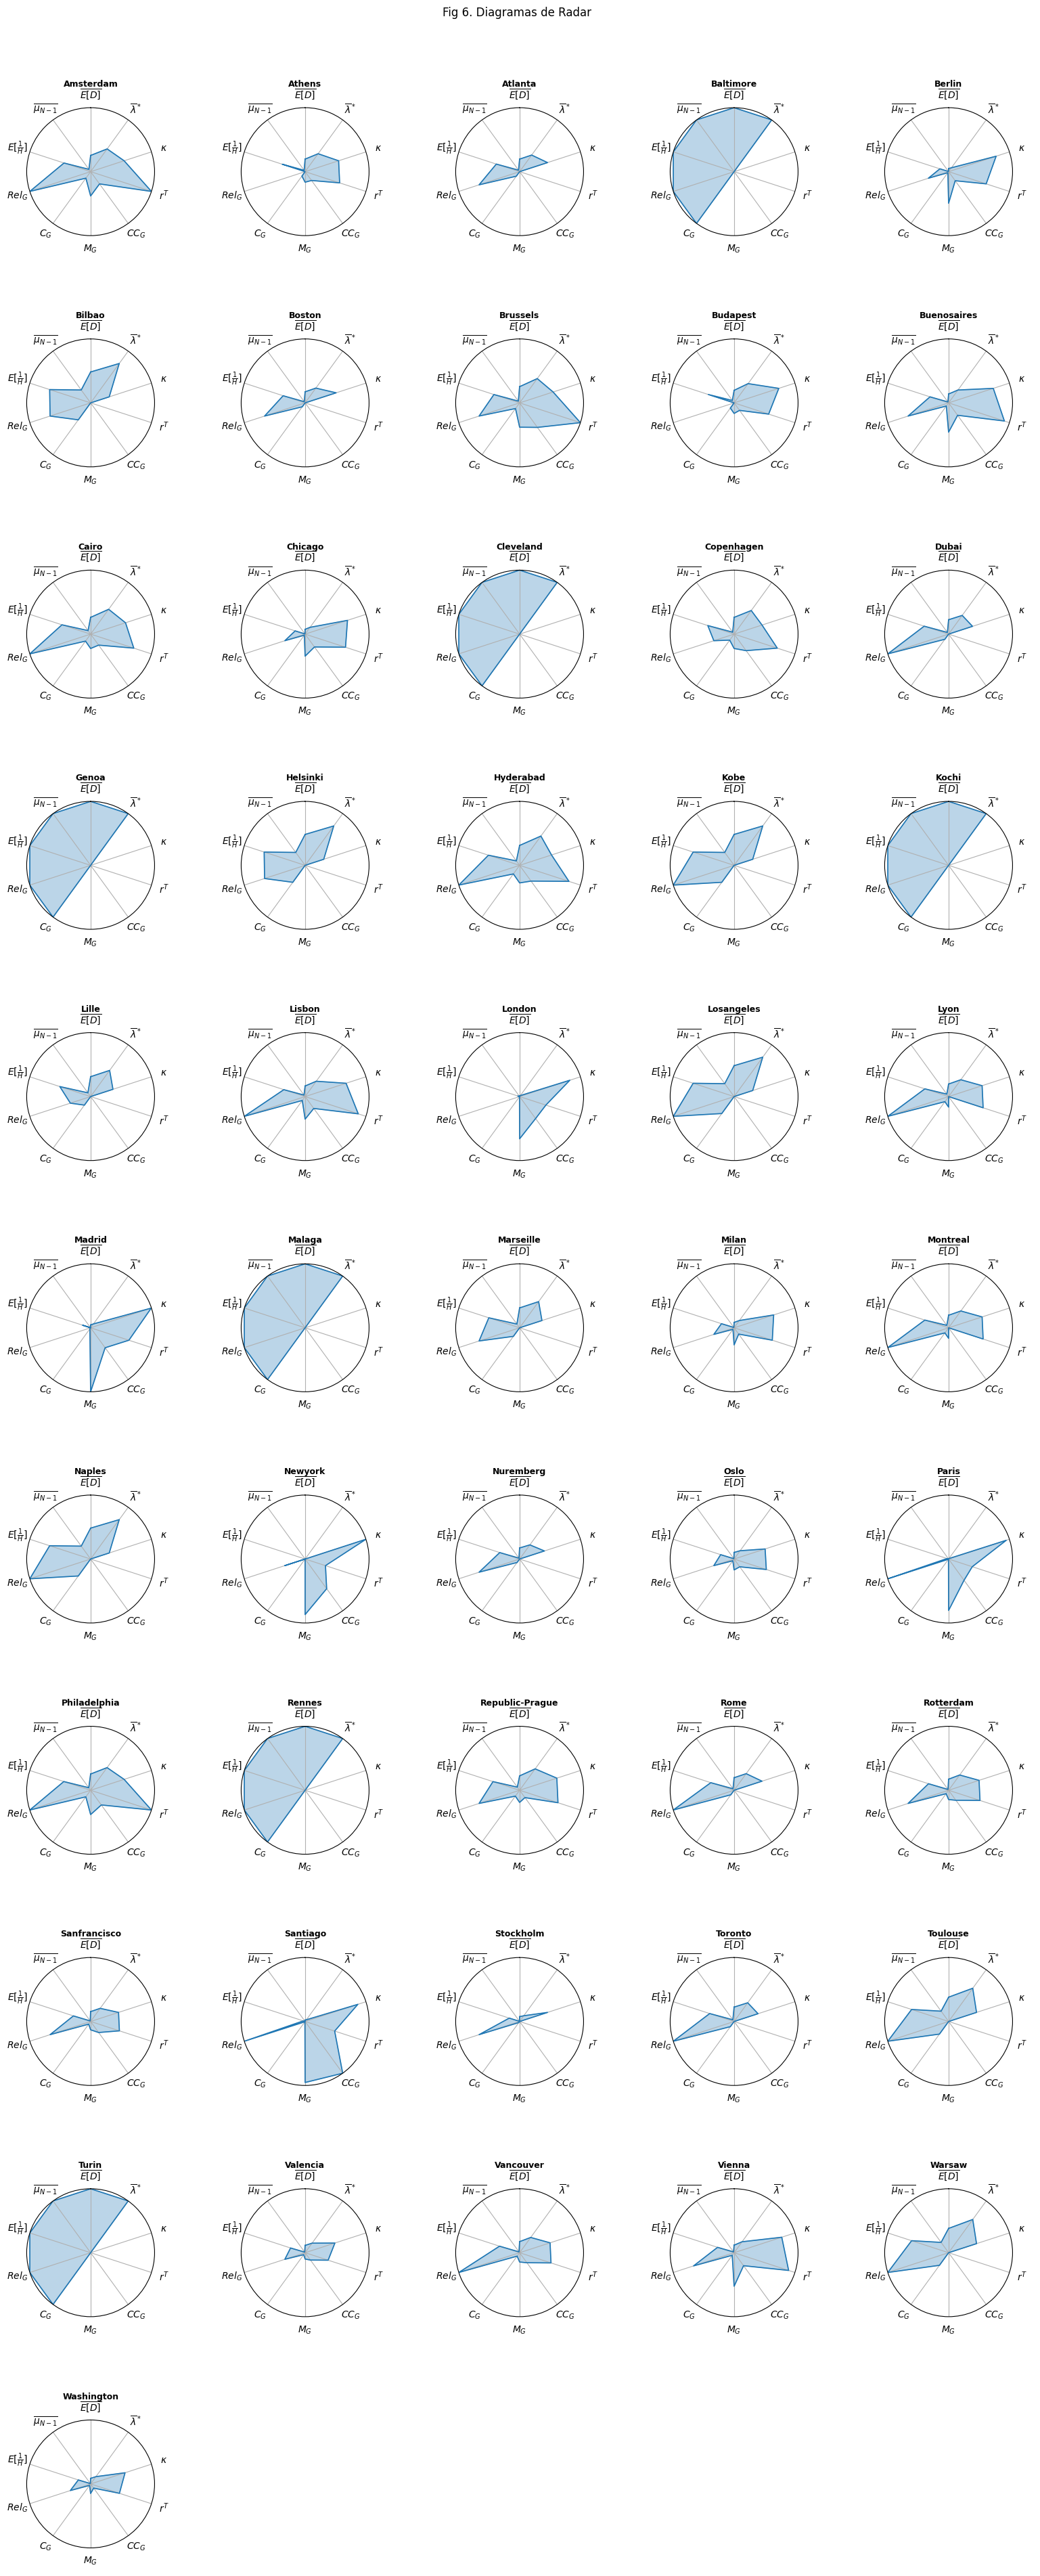

In [ ]:
# @title Fig 6. Diagramas de Radar
metrics_ordered = [
    'Avg_Deg', 'Nat_Conn', 'Kappa',
    'r_T', 'Clustering', 'Meshedness',
    'C_G', 'Rel_G', 'Efficiency', 'Alg_Conn'
]

labels_radar = [
    r'$\overline{E[D]}$', r'$\overline{\lambda}^*$', r'$\kappa$',
    r'${r^T}$', r'$CC_G$', r'$M_G$',
    r'$C_G$', r'$Rel_G$', r'$E[\frac{1}{H}]$', r'$\overline{\mu_{N-1}}$'
]

if 'df_final' in locals():
    df_radar = df_final.copy()

    # Normalización global [0,1]
    for col in metrics_ordered:
        if col in df_radar.columns:
            min_val = df_radar[col].min()
            max_val = df_radar[col].max()
            if max_val - min_val > 0:
                df_radar[col] = (df_radar[col] - min_val) / (max_val - min_val)
            else:
                df_radar[col] = 0.5
        else:
            df_radar[col] = 0.0

    def create_radar_subplot(row, ax, title, color):
        N = len(metrics_ordered)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1]

        values = row[metrics_ordered].values.astype(float).tolist()
        values.append(values[0])

        ax.set_theta_offset(pi / 2)
        ax.set_theta_direction(-1)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels_radar, fontsize=10)

        ax.set_rlabel_position(0)
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.set_ylim(0, 1)

        ax.plot(angles, values, color=color, linewidth=1.2, linestyle='solid')
        ax.fill(angles, values, color=color, alpha=0.3)

        ax.set_title(title, size=9, weight='bold', y=1.12)

    num_cities = len(df_radar)
    cols = 5
    rows = int(np.ceil(num_cities / cols))

    fig, axs = plt.subplots(
        rows, cols,
        subplot_kw={'projection': 'polar'},
        figsize=(16, 3.5 * rows)
    )

    axs_flat = np.array(axs).flatten()

    for i, (idx, row) in enumerate(df_radar.iterrows()):
        ax = axs_flat[i]
        color = '#1f77b4'
        create_radar_subplot(row, ax, row['City'], color)

    for i in range(num_cities, len(axs_flat)):
        axs_flat[i].axis('off')

    plt.subplots_adjust(hspace=0.25, wspace=0.25)

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    shrink = 0.75 # ACHICA EL RADIO
    for i in range(num_cities):
        ax = axs_flat[i]
        box = ax.get_position()
        cx = box.x0 + box.width / 2.0
        cy = box.y0 + box.height / 2.0
        new_w = box.width * shrink
        new_h = box.height * shrink
        ax.set_position([
            cx - new_w / 2.0,
            cy - new_h / 2.0,
            new_w,
            new_h
        ])

    fig.suptitle("Fig 6. Diagramas de Radar", fontsize=12, y=0.995)
    fig.savefig("fig6_radar.png", dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("Error: df_final no está definido.")


#Conclusiones

Se analizó la robustez estructural de 51 redes de metro, replicando y extendiendo la metodología propuesta en el paper. A través de un enfoque basado en la ciencia de redes y la teoría de grafos, se evaluó la capacidad de estas redes de metro para resistir fallos aleatorios y ataques dirigidos. A partir de los resultados se pueden obtener las siguientes conclusiones principales:

**1. La Robustez es una Propiedad Multidimensional**

El análisis confirma que la robustez de una red de metro no puede definirse mediante una única métrica. Los resultados revelan una división entre dos objetivos de diseño contradictorios:

>**Redundancia y Complejidad**: Métricas como el Indicador de Robustez (rT) y la coeficiente de mallado (MG​) capturan la existencia de múltiples rutas alternativas y ciclos. Redes Grandes sobresalen en estas métricas, lo que las hace resistentes al colapso total (fc​) ante ataques dirigidos, ya que el flujo puede redirigirse por caminos alternativos .

>**Eficiencia y Centralización**: Métricas como la Conductancia Efectiva (CG​) y la Eficiencia (E[1/H]) valoran la rapidez de transporte y las distancias cortas. Redes más pequeñas o con topología de estrella (como Roma o redes lineales pequeñas) obtienen puntuaciones altas aquí, indicando que son muy eficientes en condiciones normales, pero frágiles ante la pérdida de nodos centrales .

**2. Impacto de la Topología en el Perfil de Robustez (Análisis de Radares)**

La visualización mediante diagramas de radar (Figura 6) permitió identificar patrones claros en las 51 redes analizadas:

>**Redes  "Línea Recta" (Pequeñas)**: Se observó que las redes pequeñas o lineales (ej. Kochi, Génova, Cleveland) presentan un perfil de robustez sesgado, llenando casi el 100% del área de Eficiencia pero con valores cercanos a cero en Redundancia. Esto se debe a la simplificación topológica por que al eliminar nodos de grado 2, estas se redujeron al minimo, haciéndolas extremadamente eficientes pero críticas ante fallos de enlace.

>**Redes "Telaraña" (Grandes)**: Las redes grandes mostraron que a medida que una red crece, tiende a sacrificar eficiencia  E[1/H] (debido a la mayor cantidad de saltos necesarios) a cambio de una mayor resistencia estructural.

3. Correlación entre Teoría y Simulación

Las simulaciones de ataque validaron la utilidad de las métricas teóricas para predecir robustez, eliminando la necesidad de costosas simulaciones computacionales para evaluaciones preliminares:

>La Conductancia Efectiva (CG​) demostró ser un excelente predictor del umbral de fallo inicial (f90%​), es decir, cuándo la red comienza a perder funcionalidad significativa .

>El Indicador de Robustez (rT) y la Diversidad de Grado (κ) mostraron una fuerte correlación con el punto de colapso total (fc​), siendo indicadores clave para la supervivencia de la red ante ataques severos .

En resumen, mientras que las redes pequeñas priorizan la eficiencia del viaje, la evolución natural hacia redes robustas requiere la inversión en redundancia, un punto crítico para garantizar el funcionamiento y la movilidad frente a interrupciones inesperadas.

# [Repositorio GIt con aplicacion y TAREA](https://github.com/davidacaceres/cs_redes/tree/main/Tarea%203/python)

